In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [2]:
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
# df.hist(figsize=(20,20))
# from tabulate import tabulate

# nulls = df.isnull().sum().reset_index()
# nulls.columns = ['Column', 'Missing Values']
# print(tabulate(nulls, headers='keys', tablefmt='psql'))
# print(df.shape)

#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.describe()
# df_clean.hist(figsize=(20,20))
# print(df_clean.isnull().sum())
df_clean['Diabetes_Status'].value_counts()

Diabetes_Status
0.0    2785
1.0     382
Name: count, dtype: int64

In [3]:
X = df_clean[["HbA1c"]]
y = df_clean["Diabetes_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train ratio:\n", y_train.value_counts(normalize=True))
print("Valid ratio:\n", y_test.value_counts(normalize=True))

X.shape, y.shape

Train ratio:
 Diabetes_Status
0.0    0.879195
1.0    0.120805
Name: proportion, dtype: float64
Valid ratio:
 Diabetes_Status
0.0    0.880126
1.0    0.119874
Name: proportion, dtype: float64


((3167, 1), (3167,))

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [5]:
over = SMOTE()
under = RandomUnderSampler()

preprocessor_SMOTE = ColumnTransformer(
    transformers=[('num', StandardScaler(), ["HbA1c"])],
    remainder='passthrough'  # keep any non-numeric features if present
)


In [34]:
print("Train class distribution:", np.bincount(y_train))
print("Valid class distribution:", np.bincount(y_test))

Train class distribution: [2227  306]
Valid class distribution: [558  76]


C:\Users\Jarmen\AppData\Local\Temp\ipykernel_20904\713017739.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Train class distribution:", np.bincount(y_train))
C:\Users\Jarmen\AppData\Local\Temp\ipykernel_20904\713017739.py:2: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Valid class distribution:", np.bincount(y_test))


In [8]:
def train_and_evaluate_model_SMOTE(models, X_train, y_train, X_valid, y_valid):
    """
    Enhanced version that returns model performance for comparison
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        if name == "Random Forest" or name == "XGBoost":
          pipe = ImbPipeline([
              ('over', over),
              ('under', under),
              ('model', model)
          ])
        else:
          pipe = ImbPipeline([
              ('preprocess', preprocessor_SMOTE),
              ('over', over),
              ('under', under),
              ('model', model)
          ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        if hasattr(pipe, "predict_proba"):
            proba = pipe.predict_proba(X_valid)
        if proba.shape[1] > 1:
            y_proba = proba[:, 1]
        else:
            y_proba = proba[:, 0]  # fallback if single column


        # Calculate multiple metrics
        roc_auc = roc_auc_score(y_valid, y_proba)
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, zero_division=0)
        recall = recall_score(y_valid, y_pred, zero_division=0)
        f1 = f1_score(y_valid, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': pipe,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_proba
        }

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_valid, y_pred, digits=2))

        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

    return results


🔹 Training Logistic Regression...
ROC-AUC: 0.9639
F1-Score: 0.6700
              precision    recall  f1-score   support

         0.0       0.98      0.89      0.94       558
         1.0       0.54      0.89      0.67        76

    accuracy                           0.89       634
   macro avg       0.76      0.89      0.80       634
weighted avg       0.93      0.89      0.91       634



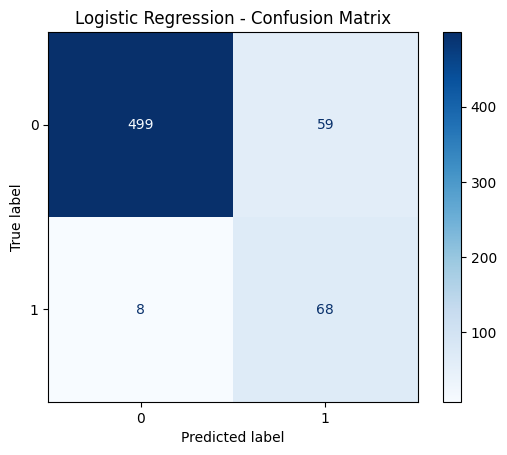


🔹 Training Random Forest...
ROC-AUC: 0.9562
F1-Score: 0.7104
              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       558
         1.0       0.61      0.86      0.71        76

    accuracy                           0.92       634
   macro avg       0.79      0.89      0.83       634
weighted avg       0.93      0.92      0.92       634



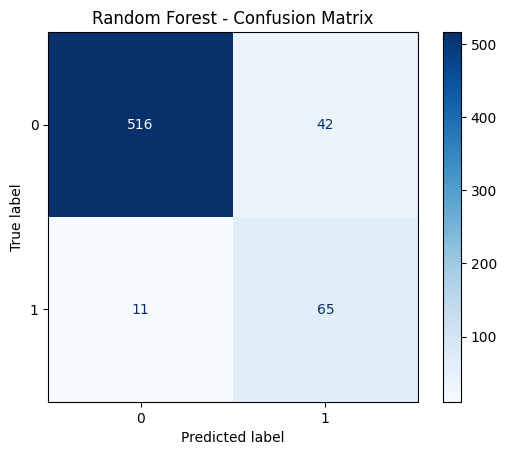


🔹 Training KNN...
ROC-AUC: 0.8157
F1-Score: 0.7328
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97       558
         1.0       0.87      0.63      0.73        76

    accuracy                           0.94       634
   macro avg       0.91      0.81      0.85       634
weighted avg       0.94      0.94      0.94       634



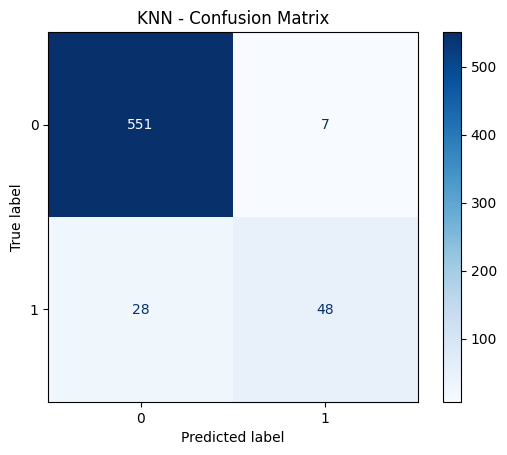


🔹 Training Naive Bayes...
ROC-AUC: 0.9622
F1-Score: 0.7190
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       558
         1.0       0.71      0.72      0.72        76

    accuracy                           0.93       634
   macro avg       0.84      0.84      0.84       634
weighted avg       0.93      0.93      0.93       634



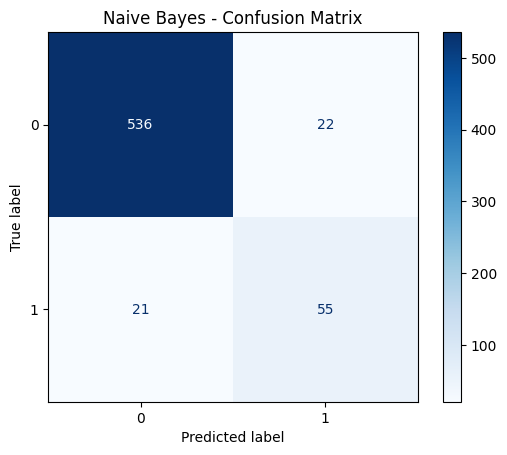


🔹 Training SVM...
ROC-AUC: 0.9558
F1-Score: 0.6700
              precision    recall  f1-score   support

         0.0       0.98      0.89      0.94       558
         1.0       0.54      0.89      0.67        76

    accuracy                           0.89       634
   macro avg       0.76      0.89      0.80       634
weighted avg       0.93      0.89      0.91       634



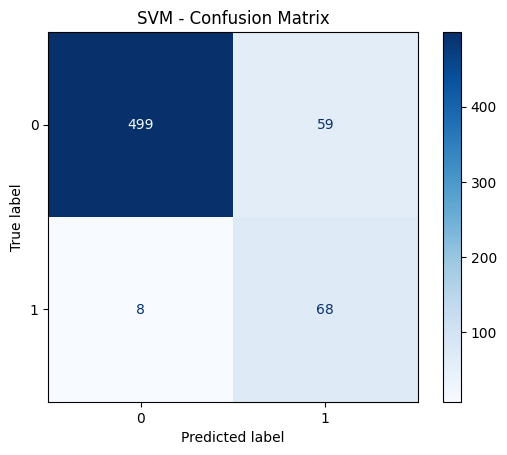


🔹 Training XGBoost...
ROC-AUC: 0.9576
F1-Score: 0.6228
              precision    recall  f1-score   support

         0.0       0.99      0.85      0.92       558
         1.0       0.47      0.93      0.62        76

    accuracy                           0.86       634
   macro avg       0.73      0.89      0.77       634
weighted avg       0.93      0.86      0.88       634



c:\REPOS\thesis_diabetes\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:25:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


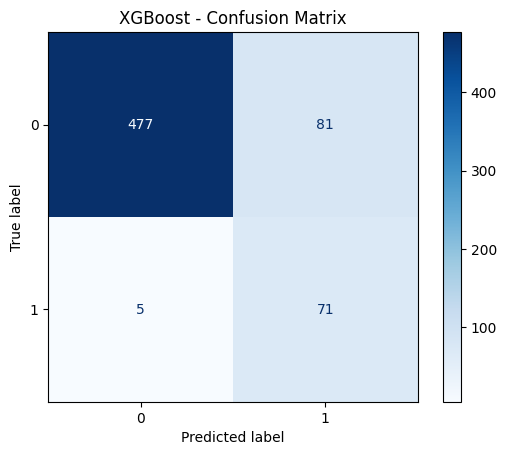

🏆 Best: Logistic Regression with AUC: 0.9639


In [7]:
# 1. Run the function
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test) 

# 2. Find the best model name based on ROC-AUC
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])

# 3. Extract the actual model and the score safely
best_model_pipeline = results[best_model_name]['model']
best_score = results[best_model_name]['roc_auc']

print(f"🏆 Best: {best_model_name} with AUC: {best_score:.4f}")

In [9]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor_SMOTE),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(max_iter=1000,
                                                random_state=42,
                                                penalty='l2',
                                                C=0.1,
                                                class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('over', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

train_df = pd.read_csv('merged_data.csv')
numeric_features = ['Age', 'Gender','Systolic_BP', 'Diastolic_BP', 
                    'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL']

# Map target (NHANES: 1=Diabetic, 2=Non-Diabetic -> 1=Positive, 0=Negative)
train_df['Diabetes_Status'] = train_df['Diabetes_Status'].map({1: 1, 2: 0})
train_df = train_df.dropna(subset=['Diabetes_Status'])

X = train_df[numeric_features]
y = train_df['Diabetes_Status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', ImbPipeline([
            ('imputer', SimpleImputer(strategy='mean')), 
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', SMOTE(random_state=42)),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=1,
        class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)

# 1. Grab the first row of your training data
sample_row = X_train.iloc[[3]] 
print("--- Raw Row ---")
print(sample_row)

# 2. Run it through JUST the preprocessor part of your pipe
# Note: we use the fitted preprocessor from your best_pipe
vector = best_pipe.named_steps['preprocess'].transform(sample_row)


# Extract the names of the columns after they were processed
feature_names = best_pipe.named_steps['preprocess'].get_feature_names_out()

# Create a beautiful DataFrame to show Zain exactly what is what
vector_mapping = pd.DataFrame(vector, columns=feature_names)

print("--- Translated Feature Vector ---")
print(vector_mapping.T) # .T transposes it for easier reading

--- Raw Row ---
       Age  Gender  Systolic_BP  Diastolic_BP  HbA1c    FBS  \
6674  53.0       1        118.0          81.0    5.4  115.0   

      Cholesterol_Total   HDL  
6674              182.0  66.0  
--- Translated Feature Vector ---
                               0
num__Age                0.580233
num__Gender            -1.067437
num__Systolic_BP       -0.073647
num__Diastolic_BP       0.882295
num__HbA1c             -0.369200
num__FBS                0.433145
num__Cholesterol_Total  0.031110
num__HDL                1.084852


In [39]:
ccmc = pd.read_excel('ccmc_dataset/COMPILED_DATASET.xlsx')


ccmc = ccmc.dropna(subset=['HbA1c'])
chol_conversion = 38.67


if ccmc['Gender'].dtype == 'object':
    ccmc['Gender'] = ccmc['Gender'].astype(str).str.upper().str.strip()
    ccmc['Gender'] = ccmc['Gender'].map({'M': 1, 'MALE': 1, 'F': 2, 'FEMALE': 2})


for col in numeric_features:
    if col in ccmc.columns and col != 'Gender':
        ccmc[col] = pd.to_numeric(ccmc[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')


ccmc['y_true'] = ccmc['Diabetes_Status'].fillna(0).astype(int)

ccmc.head()

,Age,Gender,Weight_kg,Systolic_BP,Diastolic_BP,HbA1c,FBS,Cholesterol_Total,HDL,RBS,LDL,TG,SGPT,SGOT,VLDL,Diabetes_Status,STATUS,y_true
0,55.0,2.0,NaN,120.0,70.0,11.00,16.09,5.18,1.21,220.0,3.18,1.71,14.98,NaN,0.34,1,NaN,1
2,60.0,2.0,NaN,110.0,70.0,8.88,12.20,5.25,1.05,NaN,2.20,4.30,19.00,NaN,1.95,1,NaN,1
3,51.0,2.0,NaN,100.0,70.0,4.80,4.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,1
4,74.0,NaN,NaN,110.0,80.0,10.10,8.20,4.60,0.95,NaN,2.60,2.29,11.00,NaN,1.04,1,GDM,1
6,56.0,1.0,NaN,140.0,90.0,9.50,147.66,NaN,NaN,261.0,NaN,NaN,55.00,38.9,NaN,1,NaN,1


Loading training data...
Training model
------------------------------
HOSPITAL DATA RESULTS
Total Patients: 163
Correct: 153 (93.87%)
Wrong: 10 (6.13%)
------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.94      0.97       163

    accuracy                           0.94       163
   macro avg       0.50      0.47      0.48       163
weighted avg       1.00      0.94      0.97       163



c:\REPOS\thesis_diabetes\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\REPOS\thesis_diabetes\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\REPOS\thesis_diabetes\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


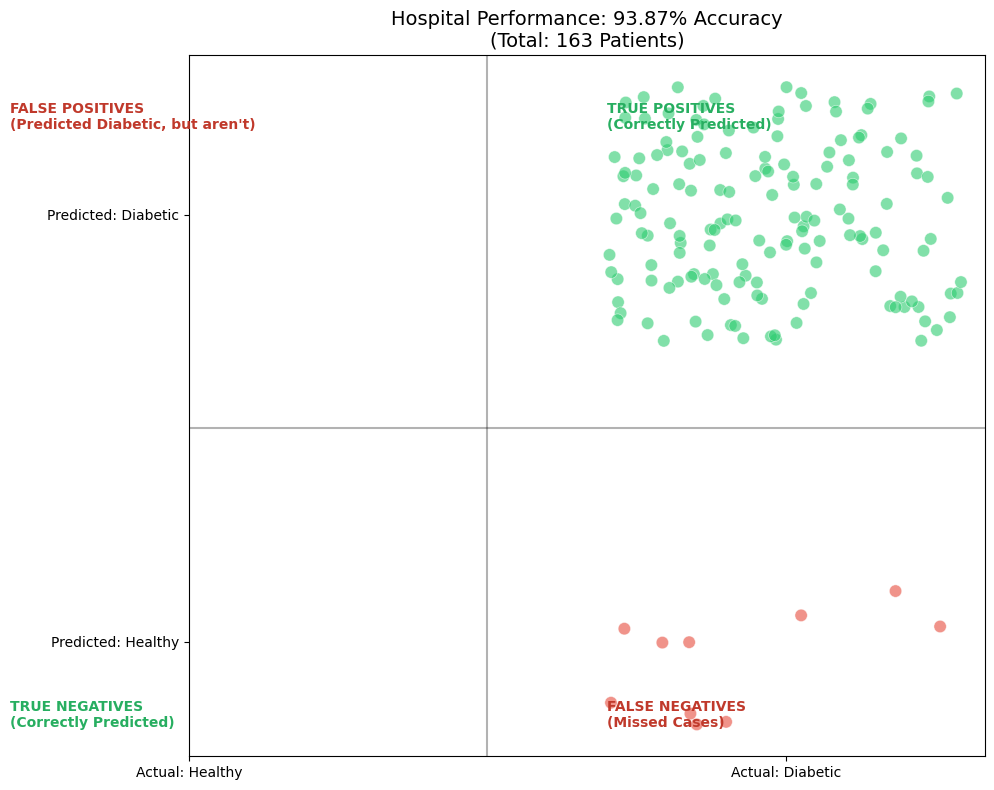

,Age,Gender,Systolic_BP,Diastolic_BP,HbA1c,FBS,Cholesterol_Total,HDL,Age_HbA1c
0,55.0,2.0,120.0,70.0,11.00,289.7809,200.3106,46.7907,605.0
2,60.0,2.0,110.0,70.0,8.88,219.7220,203.0175,40.6035,532.8
3,51.0,2.0,100.0,70.0,4.80,89.8699,NaN,NaN,244.8
4,74.0,NaN,110.0,80.0,10.10,147.6820,177.8820,36.7365,747.4
6,56.0,1.0,140.0,90.0,9.50,147.6600,NaN,NaN,532.0


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

# ==========================================
# 1. LOAD & PREPARE TRAINING DATA
# ==========================================
print("Loading training data...")
train_df = pd.read_csv('merged_data.csv')

# Define features used in training -
#numeric_features = ['HbA1c']
#numeric_features = ['Age', 'Gender', 'Systolic_BP', 'Diastolic_BP', 
#                    'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL']
numeric_features = ['Age', 'Gender', 'Systolic_BP', 'Diastolic_BP', 
                    'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL', 'Age_HbA1c']

# Map target (NHANES: 1=Diabetic, 2=Non-Diabetic -> 1=Positive, 0=Negative)
train_df['Diabetes_Status'] = train_df['Diabetes_Status'].map({1: 1, 2: 0})
train_df = train_df.dropna(subset=['Diabetes_Status'])
ccmc = pd.read_excel('ccmc_dataset/COMPILED_DATASET.xlsx')


train_df['Age_HbA1c'] = train_df['Age'] * train_df['HbA1c']
ccmc['Age_HbA1c'] = ccmc['Age'] * ccmc['HbA1c']
X = train_df[numeric_features]
y = train_df['Diabetes_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')), 
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)

# best_pipe = ImbPipeline([
#     ('preprocess', preprocessor),
#     ('over', SMOTE(random_state=42, sampling_strategy=0.6)),
#     ('under', RandomUnderSampler(random_state=42)),
#     ('model', LogisticRegression(
#         max_iter=1000,
#         random_state=42,
#         penalty='l2',
#         C=10.0,
#         class_weight={0: 1, 1: 6}
#     ))
# ])
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', SMOTE(random_state=42, sampling_strategy=0.6)),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=10.0,
        class_weight={0: 1, 1: 6}
    ))
])
print("Training model")
best_pipe.fit(X_train, y_train)




ccmc = ccmc.dropna(subset=['HbA1c'])
chol_conversion = 38.67


if ccmc['Gender'].dtype == 'object':
    ccmc['Gender'] = ccmc['Gender'].astype(str).str.upper().str.strip()
    ccmc['Gender'] = ccmc['Gender'].map({'M': 1, 'MALE': 1, 'F': 2, 'FEMALE': 2})


for col in numeric_features:
    if col in ccmc.columns and col != 'Gender':
        ccmc[col] = pd.to_numeric(ccmc[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')


ccmc['y_true'] = ccmc['Diabetes_Status'].fillna(0).astype(int)

# 1. Update Total Cholesterol
# If value is > 100, we assume it's mg/dL and divide it to get mmol/L
ccmc.loc[ccmc['Cholesterol_Total'] < 25, 'Cholesterol_Total'] = ccmc['Cholesterol_Total'] * chol_conversion


ccmc.loc[ccmc['HDL'] < 15, 'HDL'] = ccmc['HDL'] * chol_conversion
if 'FBS' in ccmc.columns:
    ccmc.loc[ccmc['FBS'] < 25, 'FBS'] *= 18.01
# Clip extreme outliers to reasonable clinical ranges
ccmc['Age'] = ccmc['Age'].clip(0, 100)
ccmc['Systolic_BP'] = ccmc['Systolic_BP'].clip(40, 250)
ccmc['Diastolic_BP'] = ccmc['Diastolic_BP'].clip(30, 150)

X_hospital = ccmc[numeric_features]

ccmc['y_pred'] = best_pipe.predict(X_hospital)
ccmc['risk_score'] = best_pipe.predict_proba(X_hospital)[:, 1]
ccmc['y_pred'] = (ccmc['risk_score'] > 0.50).astype(int)

total = len(ccmc)
correct = (ccmc['y_pred'] == ccmc['y_true']).sum()
wrong = total - correct
accuracy = (correct / total) * 100

print("-" * 30)
print(f"HOSPITAL DATA RESULTS")
print(f"Total Patients: {total}")
print(f"Correct: {correct} ({accuracy:.2f}%)")
print(f"Wrong: {wrong} ({100 - accuracy:.2f}%)")
print("-" * 30)

print(classification_report(ccmc['y_true'], ccmc['y_pred']))
plt.figure(figsize=(10, 8))

xjitter = ccmc['y_true'] + np.random.uniform(-0.3, 0.3, size=len(ccmc))
yjitter = ccmc['y_pred'] + np.random.uniform(-0.3, 0.3, size=len(ccmc))


colors = ['#2ecc71' if row['y_pred'] == row['y_true'] else '#e74c3c' for _, row in ccmc.iterrows()]

plt.scatter(xjitter, yjitter, c=colors, s=80, alpha=0.6, edgecolors='white', linewidth=0.5)


plt.axhline(y=0.5, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0.5, color='black', linestyle='-', alpha=0.3)


plt.text(-0.3, 1.2, "FALSE POSITIVES\n(Predicted Diabetic, but aren't)", color='#c0392b', fontweight='bold')
plt.text(0.7, 1.2, "TRUE POSITIVES\n(Correctly Predicted)", color='#27ae60', fontweight='bold')
plt.text(-0.3, -0.2, "TRUE NEGATIVES\n(Correctly Predicted)", color='#27ae60', fontweight='bold')
plt.text(0.7, -0.2, "FALSE NEGATIVES\n(Missed Cases)", color='#c0392b', fontweight='bold')

plt.xticks([0, 1], ["Actual: Healthy", "Actual: Diabetic"])
plt.yticks([0, 1], ["Predicted: Healthy", "Predicted: Diabetic"])
plt.title(f"Hospital Performance: {accuracy:.2f}% Accuracy\n(Total: {total} Patients)", fontsize=14)
plt.grid(False)

plt.tight_layout()
plt.show()
X_hospital.head()